# Beaver dam detection from SAR

**OBJECTIVE**: This notebook evaluates the ability of Sentinel-1 and SAOCOM SAR backscatter features to discriminate between beaver dam presence and absence at the pixel level in Tierra del Fuego.

Google Earth Engine is used to prepare the data (SAR composites and sampled point locations). All modelling, tuning, validation, and interpretation are performed here.

In [1]:
# =====================================================================
# 0. SETUP
# =====================================================================

# We import all the libraries and tools that we are going to use in this project.
# We retrieve all the packages from the UCL's Centre for Advanced Spatial Analysis (CASA)'s Computer Environment.
# For more information, you can visit https://ucl-casa.github.io/sds/ 
# Also, we use the `esda` library for exploratory spatial data analysis and `libpysal` for spatial data science.
!pip install esda libpysal

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.spatial import cKDTree

# Methodology: We choose a Random Forest algorithm classifier to discriminate between beaver dam presence and absence. 
from sklearn.ensemble import RandomForestClassifier

# Pipeline and preprocessing
from sklearn.model_selection import train_test_split, GroupKFold

# Metrics and interpretation
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             cohen_kappa_score, roc_auc_score, average_precision_score)
from sklearn.inspection import permutation_importance


# Spatial Analysis
from libpysal.weights import DistanceBand, w_difference
from esda.moran import Moran


##########################
# Parmeters and Settings #
##########################

# We set the parameters that will be used throughout the notebook.

# We set a random seed for reproducibility of results. 
# This ensures that the random processes in the code (like data splitting) produce the same results each time the code is run.
SEED = 17
np.random.seed(SEED)

# We set the working directory.
os.chdir('/home/jovyan/work/Desktop/R/UCL/Dissertation/dissertation_scripts/')

# We set the buffer size in meters that was applied around every mapped dam when sampling negatives.
# This buffer is used to avoid sampling negative points too close to known dam locations, which could lead to biased model training and evaluation.
BUFFER_M = 30 

In [2]:
# =====================================================================
# 1. DATA PRESENTATION
# =====================================================================

# We set the path to our data file.
PATH_DATA = "data/rf_points_dataset.csv"

# We upload our data. It contains the our sample of points: the mapped beaver dams and the random points sampled in GEE.
pixels = pd.read_csv(PATH_DATA)

# We rename our variable class into "dam".
pixels = pixels.rename(columns={'class': 'dam'})

print("=== BEAVER DAMs DATASET ===")
print(f"Our dataset has {pixels.shape[0]:,} rows and {pixels.shape[1]} columns.")
print("Columns:", list(pixels.columns))

=== BEAVER DAMs DATASET ===
Our dataset has 142,651 rows and 10 columns.
Columns: ['dam', 'source', 'x', 'y', 's1_VV', 's1_VH', 's1_ratio', 'sao_HH', 'sao_HV', 'sao_ratio']


In [3]:
# Let's have a quick look to it
pixels.head()

,dam,source,x,y,s1_VV,s1_VH,s1_ratio,sao_HH,sao_HV,sao_ratio
0,1,inventory,623575.0,3.935245e+06,-11.360855,-16.683250,5.322395,-4.455642,-12.008182,7.552539
1,1,inventory,601645.0,3.959025e+06,-13.544585,-21.773311,8.228726,-14.438659,-21.423720,6.985061
2,1,inventory,662375.0,3.936565e+06,-11.171664,-19.768988,8.597324,-9.626340,-17.332139,7.705799
3,1,inventory,661565.0,3.936955e+06,-14.540333,-23.730745,9.190413,-8.018478,-17.654228,9.635750
4,1,inventory,658075.0,3.940315e+06,-11.350133,-20.170481,8.820347,-5.937492,-11.921272,5.983780


Our dataset has 142,651 points. Each point contain information about 10 variables. The presence or absence of dams, the source of the information, the coordinates, and the backscatter features of each satellite.

In [4]:
# Lets's see our missing values.
pixels.isna().sum().sort_values(ascending=False)

dam          0
source       0
x            0
y            0
s1_VV        0
s1_VH        0
s1_ratio     0
sao_HH       0
sao_HV       0
sao_ratio    0
dtype: int64

Our dataset has no missing values in any of its features.

In [5]:
# Now, let's have a look to our target variable, `dam`.
# If `dam` == 1, there is a beaver's dam
# If `dam` == 0, there is not a beaver's dam

print("\n=== CLASS BALANCE ===")
pixels['dam'].value_counts()


=== CLASS BALANCE ===


dam
0    114402
1     28249
Name: count, dtype: int64

The class distribution is imbalanced, with mapped dams representing the minority class in the real world. 28,249 records correspond to beaver dams. 114,402 records correspond to pseudo negatives randomly selected further than 30 meters from any mapped dam locations.

In [6]:
# We arrange data into a features matrix and target vector.
# SENTINEL-1
FEATURES_S1      = ['s1_VV', 's1_VH', 's1_ratio']
# SAOCOM
FEATURES_SAOCOM  = ['sao_HH', 'sao_HV', 'sao_ratio']

# Combine into the full feature list
FEATURES = FEATURES_S1 + FEATURES_SAOCOM

In [7]:
# We run a quick exploratory data analysis to understand the distribution of our features and their relationship with the target variable.
# Class balance
print("\nBy 'source':")
print(pixels.groupby(['dam', 'source']).size())
 
# Let's build a summary of our variables.
print("\n=== FEATURE RANGES (describe) ===")
print(pixels[FEATURES].describe(percentiles=[.05, .5, .95]).T.round(3))
 


By 'source':
dam  source   
0    random       114402
1    inventory     28249
dtype: int64

=== FEATURE RANGES (describe) ===
              count    mean    std     min      5%     50%     95%     max
s1_VV      142651.0 -11.235  2.732 -27.486 -15.513 -11.284  -6.902  13.119
s1_VH      142651.0 -18.853  3.492 -45.242 -24.858 -18.634 -13.726   2.652
s1_ratio   142651.0   7.617  2.624  -1.483   3.771   7.380  12.302  28.513
sao_HH     142651.0  -9.173  3.205 -27.482 -14.583  -9.058  -4.299  17.033
sao_HV     142651.0 -17.332  5.425 -77.026 -26.270 -16.372 -10.447   0.629
sao_ratio  142651.0   8.159  3.669  -2.404   3.483   7.627  14.010  61.072


In [8]:
# We calculate the linear distance from each pseudo-negative point to the nearest mapped dam location
dam_xy = pixels.loc[pixels['dam'] == 1, ['x', 'y']].values
tree = cKDTree(dam_xy)
# For a positive, the nearest neighbour is itself (dist 0). In that case, we take the 2nd nearest neighbour (k=2).
dist, _ = tree.query(pixels[['x', 'y']].values, k=2)
pixels['dist_to_dam'] = np.where(pixels['dam'] == 1, dist[:, 1], dist[:, 0])
 
# For a negative, the 1st neighbour is already a real dam.
neg_dist = pixels.loc[pixels['dam'] == 0, 'dist_to_dam']
print("\n=== Distance to mapped dams (pseudo-negatives) ===")
print(f"min={neg_dist.min():.1f}  p5={neg_dist.quantile(.05):.1f}  "
      f"p50={neg_dist.quantile(.5):.1f}  p95={neg_dist.quantile(.95):.1f}  "
      f"max={neg_dist.max():.1f}")
print(f"negatives closer than {BUFFER_M} m to a dam: {(neg_dist < BUFFER_M).sum()}  "
      f"(expected ~0 given the buffer)")

# We enforce an exact 30m buffer from the mapped dams to drop the few negatives that the rasterized GEE buffer left between MIN_NEG_DIST and the pixel-grid edge.
before_filter = len(pixels)
pixels = pixels[~((pixels['dam'] == 0) & (pixels['dist_to_dam'] < 30))].reset_index(drop=True)
print(f"Negatives dropped by exact {30} m buffer: {before_filter - len(pixels)}")
 
# --- Modelling frame summary ---
print("\n=== NEW MODELLING FRAME ===")
print(f"Total: {len(pixels):,} | positives: {(pixels['dam'] == 1).sum():,} | "
      f"negatives: {(pixels['dam'] == 0).sum():,}")
print(f"Columns: {list(pixels.columns)}")


=== Distance to mapped dams (pseudo-negatives) ===
min=22.4  p5=58.3  p50=314.0  p95=1163.5  max=3669.9
negatives closer than 30 m to a dam: 260  (expected ~0 given the buffer)
Negatives dropped by exact 30 m buffer: 260

=== NEW MODELLING FRAME ===
Total: 142,391 | positives: 28,249 | negatives: 114,142
Columns: ['dam', 'source', 'x', 'y', 's1_VV', 's1_VH', 's1_ratio', 'sao_HH', 'sao_HV', 'sao_ratio', 'dist_to_dam']


260 pseudo-negatives were removed. The total negative class is now 114,142 points, making our full dataset 142,391 points.

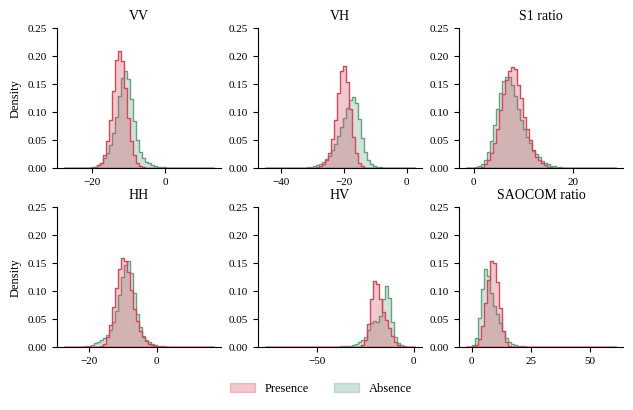

In [23]:
# Let's inspect the distribution of our features by class (dam presence / absence).
# We first define the class labels and the colour palette for plotting.
LABELS = {1: "Presence", 0: "Absence"}
PALETTE = {"Presence": "#d1495b", "Absence": "#66a182"}

# Clean labels for panel titles, so the figure is easier to read in the dissertation.
FEATURE_LABELS = {
    "s1_VV": "VV",
    "s1_VH": "VH",
    "s1_ratio": "S1 ratio",
    "sao_HH": "HH",
    "sao_HV": "HV",
    "sao_ratio": "SAOCOM ratio"
}

# Temporary display column just for plotting; the model still uses dam as 1/0.
plot_df = pixels.copy()
plot_df["condition"] = plot_df["dam"].map(LABELS)

# Set the layout of the small multiples.
ncols = 3
nrows = int(np.ceil(len(FEATURES) / ncols))

# Start from a clean figure so repeated runs in Jupyter do not accumulate objects.
plt.close("all")

# Create the figure and axes.
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16 / 2.54, 10 / 2.54)   # size in inches (converted from cm)
)

axes = axes.flatten()

# Draw one histogram per feature.
for i, feat in enumerate(FEATURES):

    sns.histplot(
        data=plot_df,
        x=feat,
        hue="condition",
        stat="density",
        common_norm=False,   # normalise each class separately so shapes are comparable
        bins=50,
        element="step",
        fill=True,
        alpha=0.30,
        palette=PALETTE,
        ax=axes[i],
        legend=False         # suppress subplot legends; we will add one global legend later
    )

    # Use cleaner panel titles instead of raw variable names.
    axes[i].set_title(
        FEATURE_LABELS.get(feat, feat),
        fontfamily="Liberation Serif",
        fontsize=10
    )

    # Remove repeated x-axis labels to keep the figure clean.
    axes[i].set_xlabel("")

    # Use the same y-axis range for every panel so densities
    # can be compared directly across predictors.
    axes[i].set_ylim(0, 0.25)

    # Use the same y-axis ticks in every panel.
    axes[i].set_yticks(
        [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]
    )

    # Keep the y-axis title only in the first column.
    # Tick marks and tick labels remain visible in all panels.
    if i % ncols == 0:
        axes[i].set_ylabel(
            "Density",
            fontfamily="Liberation Serif",
            fontsize=9
        )
    else:
        axes[i].set_ylabel("")

    # Apply dissertation typography to x-axis ticks.
    for label in axes[i].get_xticklabels():
        label.set_fontfamily("Liberation Serif")
        label.set_fontsize(8)
        label.set_fontweight("normal")

    # Apply dissertation typography to y-axis ticks.
    for label in axes[i].get_yticklabels():
        label.set_fontfamily("Liberation Serif")
        label.set_fontsize(8)
        label.set_fontweight("normal")

    # Simplify the frame.
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)


# Turn off any unused axes if the grid has more panels than features.
for j in range(len(FEATURES), len(axes)):
    axes[j].axis("off")


# Add one global legend for the whole figure.
from matplotlib.patches import Patch

legend_handles = [
    Patch(
        facecolor=PALETTE["Presence"],
        edgecolor=PALETTE["Presence"],
        alpha=0.30,
        label="Presence"
    ),
    Patch(
        facecolor=PALETTE["Absence"],
        edgecolor=PALETTE["Absence"],
        alpha=0.30,
        label="Absence"
    )
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=2,
    frameon=False,
    prop={
        "family": "Liberation Serif",
        "size": 9
    }
)


# Adjust spacing so the panels and legend fit comfortably.
fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.14,
    top=0.95,
    wspace=0.22,
    hspace=0.28
)


# Export the figure.
fig.savefig(
    fname="viz/charts/appendix_feature_distributions.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white"
)

plt.show()

The histograms by dam presence and absence, indicate that none of the individual variables provides a clear distinction between the two classes. This suggests that dam detection cannot be reliably based on a single variable or a fixed threshold. Instead, discrimination is likely to depend on the combined information provided by multiple predictors.

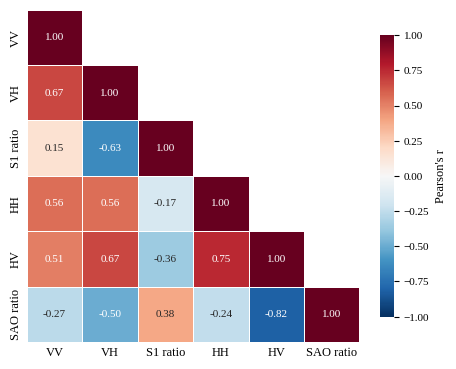

In [19]:
# Finally, we compute a Pearson correlation matrix across numeric variables to detect potential redundancy.
corr = pixels[FEATURES].corr(method='pearson')

label_map = {
    "s1_VV": "VV",
    "s1_VH": "VH",
    "s1_ratio": "S1 ratio",
    "sao_HH": "HH",
    "sao_HV": "HV",
    "sao_ratio": "SAO ratio"
}

corr = corr.rename(
    index=label_map,
    columns=label_map
)

# Mask the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.close("all")

fig, ax = plt.subplots(
    figsize=(
        12.0 *  1 / 2.54,
        10.0 *  1 / 2.54
    )
)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={
        "shrink": 0.8,
        "label": "Pearson's r"
    },
    ax=ax
)

# Export
# Color bar
cbar = ax.collections[0].colorbar

for label in cbar.ax.get_yticklabels():
    label.set_fontfamily("Liberation Serif")
    label.set_fontsize(8)

cbar.set_label(
    "Pearson's r",
    fontsize=9,
    fontfamily="Liberation Serif"
)

# Tipography and style settings for the plots
for label in ax.get_xticklabels():
    label.set_fontfamily("Liberation Serif")
    label.set_fontsize(9)

for label in ax.get_yticklabels():
    label.set_fontfamily("Liberation Serif")
    label.set_fontsize(9)

for text in ax.texts:
    text.set_fontfamily("Liberation Serif")
    text.set_fontsize(8)

# Style
ax.tick_params(length=0)

plt.tight_layout()

fig.savefig(
    fname= "viz/charts/appendix_pearson_correlation.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white"
)

plt.show()


Overall, moderate-to-high correlations occurred both within and between sensor feature sets, particularly among polarization channels and the ratio between features. However, no pair showed near-perfect correlation (Later, the substantial improvement of the combined model will indicate that correlation between sensors did not translate into complete predictive redundancy).

## Variable description

| Variable | Description | Type | Source | Spatial unit |
|---|---|---|---|---|
| `dam` | Presence (1) or absence (0) of beaver's dam | Binary (1/0) | Huertas Herrera et al (2020) inventory (presence) / random sampling (absence) | Pixel (10 m) |
| `s1_VV` | Sentinel-1 C-band co-polarised backscatter | Numeric (dB) | Sentinel-1 (ESA/Copernicus), 2025 | Pixel (10 m) |
| `s1_VH` | Sentinel-1 C-band cross-polarised backscatter | Numeric (dB) | Sentinel-1 (ESA/Copernicus), 2025 | Pixel (10 m) |
| `s1_ratio` | Sentinel-1 co-/cross-pol ratio (VV − VH) | Numeric (dB) | Derived from Sentinel-1 | Pixel (10 m) |
| `sao_HH` | SAOCOM L-band co-polarised backscatter | Numeric (dB) | SAOCOM (CONAE), 2025 | Pixel (10 m) |
| `sao_HV` | SAOCOM L-band cross-polarised backscatter | Numeric (dB) | SAOCOM (CONAE), 2025 | Pixel (10 m) |
| `sao_ratio` | SAOCOM co-/cross-pol ratio (HH − HV) | Numeric (dB) | Derived from SAOCOM | Pixel (10 m) |


*All predictors were sampled at 10 m in EPSG: 32719.*

In [ ]:
# =====================================================================
# 2. METHODOLOGY
# =====================================================================

# We define a reusable helper function used to summarize model performance across the models.
def summarize_performance(label, y_true, y_pred, y_proba):
    """Key classification metrics for BOTH classes.
    Accuracy is omitted due to the deliberate class balance in training."""
    return {
        'model':         label,
        'recall_dam':    recall_score(y_true, y_pred, pos_label=1),
        'recall_bg':     recall_score(y_true, y_pred, pos_label=0),
        'precision_dam': precision_score(y_true, y_pred, pos_label=1),
        'f1_dam':        f1_score(y_true, y_pred, pos_label=1),
        'kappa':         cohen_kappa_score(y_true, y_pred),
        'roc_auc':       roc_auc_score(y_true, y_proba),
        'pr_auc':        average_precision_score(y_true, y_proba),
    }

## Model training and evaluation
# First, we run a model with a random stratified 70/30 split that will be used as a baseline for comparison with the spatially blocked cross-validation.
def run_rf(features, label, test_size=0.3, verbose=True):
    X = pixels[features].values
    y = pixels['dam'].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, 
        test_size=test_size,
        stratify=y,
        random_state=SEED
        )

    if verbose:
        print(f"\n--- {label}: split ---")
        print(f"Train: {X_tr.shape[0]:,} samples x {X_tr.shape[1]} features")
        print(f"Test:  {X_te.shape[0]:,} samples x {X_te.shape[1]} features")
        print(f"Positive proportion -- train: {y_tr.mean():.1%} | test: {y_te.mean():.1%}")

    rf = RandomForestClassifier(
        n_estimators=500, 
        class_weight='balanced',
        random_state=SEED,
         n_jobs=-1)
    rf.fit(X_tr, y_tr)

    # Predict on both sets to quantify overfitting (train - test gap).
    m_train = summarize_performance(label, y_tr,
                rf.predict(X_tr), rf.predict_proba(X_tr)[:, 1])
    m_test  = summarize_performance(label, y_te,
                rf.predict(X_te), rf.predict_proba(X_te)[:, 1])

    if verbose:
        gap = pd.DataFrame({
            'train': m_train, 'test': m_test,
            'train-test': {k: (m_train[k] - m_test[k]) if isinstance(m_train[k], (int, float)) else ''
                           for k in m_train}
        })
        gap = gap.drop(index='model')          # drop the label row from the numeric table
        print(f"\n{label} -- train vs test:")
        print(gap.round(3).to_string())
        print("\nTest classification report:")
        print(classification_report(y_te, rf.predict(X_te), digits=3))

    return rf, m_test, (y_te, rf.predict(X_te))   # test metrics feed the comparison table

# ---- Random Split: Sentinel-1 vs SAOCOM vs Combined Model ----
results = []
rf_s1,   m_s1,   pred_s1   = run_rf(FEATURES_S1,                   "Sentinel-1 only")
rf_sao,  m_sao,  pred_sao  = run_rf(FEATURES_SAOCOM,               "SAOCOM only")
rf_both, m_both, pred_both = run_rf(FEATURES_S1 + FEATURES_SAOCOM, "S1 + SAOCOM")
results.extend([m_s1, m_sao, m_both])

# ---- Comparison table ----
results_df = pd.DataFrame(results).round(3)
print("\n=== MODEL COMPARISON (random 70/30 split) ===")
print(results_df.to_string(index=False))


--- Sentinel-1 only: split ---
Train: 99,673 samples x 3 features
Test:  42,718 samples x 3 features
Positive proportion -- train: 19.8% | test: 19.8%

Sentinel-1 only -- train vs test:
              train      test train-test
recall_dam      1.0  0.188673   0.811327
recall_bg       1.0  0.913997   0.086003
precision_dam   1.0  0.351893   0.648107
f1_dam          1.0  0.245641   0.754359
kappa           1.0  0.124375   0.875625
roc_auc         1.0  0.695493   0.304507
pr_auc          1.0  0.315536   0.684464

Test classification report:
              precision    recall  f1-score   support

           0      0.820     0.914     0.864     34243
           1      0.352     0.189     0.246      8475

    accuracy                          0.770     42718
   macro avg      0.586     0.551     0.555     42718
weighted avg      0.727     0.770     0.742     42718


--- SAOCOM only: split ---
Train: 99,673 samples x 3 features
Test:  42,718 samples x 3 features
Positive proportion -- train: 1

In [30]:
# We run a Moran's I correlogram to measure the spatial autocorrelation of the SAR features.
# This analysis helps us determine the appropriate block size for spatial cross-validation, ensuring that our model evaluation accounts for spatial dependencies in the data.

# We take a random subsample of 5000 pixels.
SUB_N = 5000
sub = pixels.sample(n=SUB_N, random_state=SEED).reset_index(drop=True)
coords = sub[['x', 'y']].values
sar_feats = FEATURES_S1 + FEATURES_SAOCOM      
edges = [0, 250, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000]  # We choose a ring boundaries approach. Each band measures autocorrelation only within a distance ring, excluding nearer neighbours.

print(f"Moran's I ring-based correlogram (n={SUB_N})")
print("each row expresses autocorrelation WITHIN that distance ring \n")
header = "ring (m)      | " + " ".join(f"{f.split('_',1)[1]:>7}" for f in sar_feats) + " |  mean"
print(header); print("-" * len(header))

# We run a loop over the specified distance bands to calculate Moran's I for each SAR feature.
# A positive Moran's I indicates that similar values cluster together, while a negative value suggests that dissimilar values are neighbors.
# The significance of the autocorrelation is assessed using permutation tests.
for i in range(1, len(edges)):
    d_lo, d_hi = edges[i-1], edges[i]
    # ring = neighbours within d_hi MINUS neighbours within d_lo
    w_hi = DistanceBand(coords, threshold=d_hi, binary=True, silence_warnings=True)
    w_ring = w_hi if d_lo == 0 else w_difference(
        w_hi, DistanceBand(coords, threshold=d_lo, binary=True, silence_warnings=True),
        constrained=False, silence_warnings=True)
    w_ring.transform = 'r'

    Is, cells = [], []
    for f in sar_feats:
        try:
            mi = Moran(sub[f].values, w_ring, permutations=99)    # How similar are the neighbors?
            mark = "" if mi.p_sim < 0.05 else "*"                # * = no significant autocorrelation at that band
            cells.append(f"{mi.I:+.2f}{mark:>1}"); Is.append(mi.I)
        except Exception:
            cells.append("   n/a")
    mean_I = np.mean(Is) if Is else float('nan')
    print(f"{d_lo:>4}-{d_hi:<5}   | " + " ".join(f"{c:>7}" for c in cells) + f" | {mean_I:+.2f}")

print("\n(* = p >= 0.05, not significant in that ring)")

Moran's I ring-based correlogram (n=5000)
each row expresses autocorrelation WITHIN that distance ring 

ring (m)      |      VV      VH   ratio      HH      HV   ratio |  mean
-----------------------------------------------------------------------
   0-250     |  +0.33   +0.39   +0.21   +0.53   +0.52   +0.36  | +0.39
 250-500     |  +0.24   +0.29   +0.11   +0.32   +0.44   +0.35  | +0.29
 500-750     |  +0.17   +0.25   +0.13   +0.20   +0.32   +0.26  | +0.22
 750-1000    |  +0.12   +0.16   +0.07   +0.13   +0.27   +0.25  | +0.17
1000-1500    |  +0.09   +0.14   +0.07   +0.09   +0.23   +0.21  | +0.14
1500-2000    |  +0.08   +0.11   +0.04   +0.08   +0.20   +0.18  | +0.11
2000-2500    |  +0.06   +0.10   +0.03   +0.05   +0.18   +0.18  | +0.10
2500-3000    |  +0.06   +0.09   +0.04   +0.06   +0.15   +0.14  | +0.09
3000-4000    |  +0.05   +0.07   +0.02   +0.03   +0.11   +0.10  | +0.06
4000-5000    |  +0.04   +0.06   +0.02   +0.03   +0.08   +0.07  | +0.05

(* = p >= 0.05, not significant in that 

The ring-based Moran’s I correlogram indicated strong short-range spatial dependence in the SAR predictors, with the highest autocorrelation occurring within the nearest distance bands. This pattern shows that neighbouring pixels are more similar than distant pixels, but that spatial dependence weakens gradually with distance rather than disappearing abruptly. The persistence of weak residual autocorrelation, even up to 5 km, indicates that spatial blocking is appropriate for reducing, but not fully eliminating, spatial autocorrelation.

In [31]:
# The 2 km block size used for spatial cross-validation was defined based on the elbow observed in Moran’s I decay. 
BLOCK_KM = 2.0   
print(f"\nBLOCK_KM set to {BLOCK_KM}")

bs = BLOCK_KM * 1000                    # block edge in metres (coords are EPSG:32719, in metres)

# We map each coordinate to its grid-cell index:
# Combining the column and row indices gives a unique cell label ("col_row").
# All pixels falling in the same 2x2 km cell share the same block_id, so they
# are always kept together (train OR test)
# This is what removes spatial leakage between folds.
pixels['block_id'] = ((pixels['x'] // bs).astype(int).astype(str) + '_' +
                      (pixels['y'] // bs).astype(int).astype(str))

# We check if are there enough blocks (with dams) for a stable k-fold CV
n_blocks   = pixels['block_id'].nunique()                              # total non-empty blocks
dam_blocks = pixels.loc[pixels['dam'] == 1, 'block_id'].nunique()      # blocks containing >=1 dam
per_block_dams = pixels[pixels['dam'] == 1].groupby('block_id').size() # dams per (dam-containing) block

print(f"BLOCK_KM={BLOCK_KM}: {n_blocks} non-empty blocks, {dam_blocks} with >=1 dam")
print(f"dams per block (of those with dams): min={per_block_dams.min()}, "
      f"median={int(per_block_dams.median())}, max={per_block_dams.max()}")


BLOCK_KM set to 2.0
BLOCK_KM=2.0: 716 non-empty blocks, 638 with >=1 dam
dams per block (of those with dams): min=1, median=32, max=262


In [32]:
# We carry a spatial cross-validation. 
# Five folds were then used with GroupKFold, so that all points within a spatial block are assigned to the same fold, preventing any block from being split between training and test. 

N_SPLITS = 5

def run_rf_spatial(features, label, n_splits=N_SPLITS):
    X = pixels[features].values
    y = pixels['dam'].values
    groups = pixels['block_id'].values

    gkf = GroupKFold(n_splits=n_splits)
    oof_true, oof_pred, oof_proba = [], [], []
    per_fold = []   # metrics computed within each fold

    for tr_idx, te_idx in gkf.split(X, y, groups):
        rf = RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            random_state=SEED, n_jobs=-1)
        rf.fit(X[tr_idx], y[tr_idx])

        yt, yp = y[te_idx], rf.predict(X[te_idx])
        ypr = rf.predict_proba(X[te_idx])[:, 1]
        oof_true.append(yt); oof_pred.append(yp); oof_proba.append(ypr)

        # metric for this fold (ROC-AUC and PR-AUC, threshold-independent)
        per_fold.append({
            'roc_auc': roc_auc_score(yt, ypr),
            'pr_auc':  average_precision_score(yt, ypr),
        })

    # pooled out-of-fold metrics
    y_true  = np.concatenate(oof_true)
    y_pred  = np.concatenate(oof_pred)
    y_proba = np.concatenate(oof_proba)
    m = summarize_performance(label, y_true, y_pred, y_proba)

    # per-fold summary (mean +/- SD)
    pf = pd.DataFrame(per_fold)
    m['roc_auc_mean'] = pf['roc_auc'].mean(); m['roc_auc_sd'] = pf['roc_auc'].std()
    m['pr_auc_mean']  = pf['pr_auc'].mean();  m['pr_auc_sd']  = pf['pr_auc'].std()

    return m, (y_true, y_pred, y_proba), pf   # pf = per-fold table (for the significance test)

# --- Run the three models under spatial CV ---
results_spatial = []
m_s1_sp,   pred_s1_sp,   pf_s1   = run_rf_spatial(FEATURES_S1,                   "Sentinel-1 only")
m_sao_sp,  pred_sao_sp,  pf_sao  = run_rf_spatial(FEATURES_SAOCOM,               "SAOCOM only")
m_both_sp, pred_both_sp, pf_both = run_rf_spatial(FEATURES_S1 + FEATURES_SAOCOM, "S1 + SAOCOM")
results_spatial.extend([m_s1_sp, m_sao_sp, m_both_sp])

# --- Comparison table: pooled + per-fold ---
comp = pd.DataFrame(results_spatial)
cols = ['model', 'roc_auc', 'roc_auc_sd',
        'pr_auc', 'pr_auc_sd', 'recall_dam', 'recall_bg']
print("=== SPATIAL block CV: pooled vs per-fold (mean +/- SD) ===")
print(comp[cols].round(3).to_string(index=False))

=== SPATIAL block CV: pooled vs per-fold (mean +/- SD) ===
          model  roc_auc  roc_auc_sd  pr_auc  pr_auc_sd  recall_dam  recall_bg
Sentinel-1 only    0.699       0.005   0.318      0.007       0.185      0.916
    SAOCOM only    0.666       0.002   0.300      0.007       0.165      0.921
    S1 + SAOCOM    0.804       0.005   0.461      0.010       0.261      0.943


In [33]:
# Finally, we check that the folds are balanced in class proportion.
groups = pixels['block_id'].values
y = pixels['dam'].values
gkf = GroupKFold(n_splits=N_SPLITS)   # same N_SPLITS as the spatial CV

print(f"=== Fold composition ({N_SPLITS}-fold GroupKFold by 2 km block) ===")
print(f"{'fold':>4} | {'n_test':>8} | {'blocks':>6} | {'pos':>6} | {'neg':>7} | {'pos %':>6}")
print("-" * 52)
for k, (_, te_idx) in enumerate(gkf.split(pixels[FEATURES_S1], y, groups), 1):
    yte = y[te_idx]
    n_pos = int(yte.sum()); n_neg = int((yte == 0).sum())
    n_blk = pixels.iloc[te_idx]['block_id'].nunique()
    pct = n_pos / len(yte) * 100
    print(f"{k:>4} | {len(te_idx):>8,} | {n_blk:>6} | {n_pos:>6,} | {n_neg:>7,} | {pct:>5.1f}%")

print(f"\nDataset-wide positive rate: {y.mean()*100:.1f}%")

=== Fold composition (5-fold GroupKFold by 2 km block) ===
fold |   n_test | blocks |    pos |     neg |  pos %
----------------------------------------------------


   1 |   28,479 |    143 |  5,754 |  22,725 |  20.2%
   2 |   28,478 |    144 |  5,518 |  22,960 |  19.4%
   3 |   28,478 |    143 |  5,664 |  22,814 |  19.9%
   4 |   28,478 |    143 |  5,569 |  22,909 |  19.6%
   5 |   28,478 |    143 |  5,744 |  22,734 |  20.2%

Dataset-wide positive rate: 19.8%


Class proportions are balanced across folds, ranging from 19.4% to 20.2% positives compared with the 19.8% overall. No additional stratification was applied.

In [34]:
# We check for Permutation importance by sensor group of the combined model to determine feature importance.
# Scoring is average_precision (PR-AUC), consistent with the primary metric for the imbalanced problem. 
# Computed within the spatial CV scheme, in each fold the model is fitted on training blocks and importance is measured on the held-out block, so importances are out-of-fold.
# Results are aggregated by sensor group to address the complementarity question.

FEATURES_COMBINED = FEATURES_S1 + FEATURES_SAOCOM
X = pixels[FEATURES_COMBINED].values
y = pixels['dam'].values
groups = pixels['block_id'].values

gkf = GroupKFold(n_splits=N_SPLITS)
imp_per_fold = []                          # one row per fold, one column per feature

for tr_idx, te_idx in gkf.split(X, y, groups):
    rf = RandomForestClassifier(
        n_estimators=500, class_weight='balanced',
        random_state=SEED, n_jobs=-1)
    rf.fit(X[tr_idx], y[tr_idx])           # fit on training blocks

    perm_result = permutation_importance(
        rf,                                # the trained forest for this fold
        X[te_idx],                         # held-out block (out-of-fold)
        y[te_idx],
        scoring='average_precision',       # PR-AUC: robust to class imbalance
        n_repeats=10,
        random_state=SEED,
        n_jobs=1
    )
    imp_per_fold.append(perm_result.importances_mean)

imp_df = pd.DataFrame(imp_per_fold, columns=FEATURES_COMBINED)

# Build DataFrame ordered by mean importance (mean +/- SD across folds)
pi_df = pd.DataFrame({
    'feature': FEATURES_COMBINED,
    'pi_mean': imp_df.mean().values,
    'pi_std':  imp_df.std().values
}).sort_values('pi_mean', ascending=False).reset_index(drop=True)
print("\n=== Permutation Importance per feature (spatial CV, drop in PR-AUC) ===")
print(pi_df.to_string(index=False))

# Aggregate by sensor group (the complementarity question)
s1_imp  = imp_df[FEATURES_S1].sum(axis=1)      # total S1 importance per fold
sao_imp = imp_df[FEATURES_SAOCOM].sum(axis=1)  # total SAOCOM importance per fold
total   = s1_imp + sao_imp

group_df = pd.DataFrame({
    'sensor':  ['Sentinel-1', 'SAOCOM'],
    'pi_mean': [s1_imp.mean(), sao_imp.mean()],
    'pi_std':  [s1_imp.std(),  sao_imp.std()],
    'share_%': [100 * (s1_imp / total).mean(), 100 * (sao_imp / total).mean()]
}).round(4)
print("\n=== Permutation Importance by sensor group ===")
print(group_df.to_string(index=False))

Computing Permutation Importance (spatial CV)

=== Permutation Importance per feature (spatial CV, drop in PR-AUC) ===
  feature  pi_mean   pi_std
    s1_VH 0.104161 0.007590
    s1_VV 0.071419 0.002968
   sao_HV 0.042210 0.005520
sao_ratio 0.037795 0.002452
   sao_HH 0.024758 0.005335
 s1_ratio 0.003446 0.002274

=== Permutation Importance by sensor group ===
    sensor  pi_mean  pi_std  share_%
Sentinel-1   0.1790  0.0106    63.09
    SAOCOM   0.1048  0.0078    36.91


Permutation importance in the combined model was consistent with the sensor comparison. Sentinel-1 showed the greater aggregate predictive contribution compared with SAOCOM, which retained a substantial contribution.

In [35]:
# =====================================================================
# 2.7 Operating threshold via True Skill Statistic (TSS)
# =====================================================================
def tss_threshold(y_true, y_proba, thresholds=np.round(np.arange(0.05, 0.96, 0.05), 2), label=""):
    rows = []
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        tp = np.sum((yp==1)&(y_true==1)); fn = np.sum((yp==0)&(y_true==1))
        tn = np.sum((yp==0)&(y_true==0)); fp = np.sum((yp==1)&(y_true==0))
        sens = tp/(tp+fn); spec = tn/(tn+fp)
        rows.append((round(t,2), sens, spec, sens+spec-1))
    tab = pd.DataFrame(rows, columns=['threshold','sensitivity','specificity','TSS'])
    best = tab.loc[tab['TSS'].idxmax()]
    print(f"\n=== TSS sweep: {label} ===")
    print(tab.round(3).to_string(index=False))
    print(f"\nOptimal threshold = {best['threshold']:.2f} (TSS={best['TSS']:.3f}, "
          f"sens={best['sensitivity']:.3f}, spec={best['specificity']:.3f})")
    return float(best['threshold'])

y_true_b, _, y_proba_b = pred_both_sp
best_t = tss_threshold(y_true_b, y_proba_b, label="S1 + SAOCOM (spatial CV)")

print("\n=== 0.50 vs TSS-optimal ===")
for t in [0.50, best_t]:
    yp = (y_proba_b >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_b, yp).ravel()
    print(f"threshold={t:.2f} -> recall_dam={tp/(tp+fn):.3f} recall_bg={tn/(tn+fp):.3f} precision_dam={tp/(tp+fp):.3f}")


=== TSS sweep: S1 + SAOCOM (spatial CV) ===
 threshold  sensitivity  specificity   TSS
      0.05        0.955        0.418 0.373
      0.10        0.901        0.544 0.445
      0.15        0.836        0.630 0.466
      0.20        0.766        0.699 0.464
      0.25        0.689        0.757 0.446
      0.30        0.603        0.807 0.411
      0.35        0.519        0.850 0.369
      0.40        0.431        0.886 0.317
      0.45        0.346        0.918 0.263
      0.50        0.264        0.942 0.206
      0.55        0.194        0.962 0.156
      0.60        0.132        0.976 0.108
      0.65        0.081        0.986 0.067
      0.70        0.044        0.993 0.037
      0.75        0.021        0.997 0.018
      0.80        0.008        0.999 0.007
      0.85        0.002        1.000 0.001
      0.90        0.000        1.000 0.000
      0.95        0.000        1.000 0.000

Optimal threshold = 0.15 (TSS=0.466, sens=0.836, spec=0.630)

=== 0.50 vs TSS-optimal ===
thre

To characterize the combined model as a detector, an operating threshold was selected by maximizing the True Skill Statistic (TSS) over the pooled out-of-fold predictions.

At the selected threshold, the model detected 83.5% of mapped dam locations while correctly classifying 63.2% of pseudo-absences as negative. Because the threshold was selected from the same pooled out-of-fold predictions used to calculate these metrics, these values describe performance at the selected operating point rather than an independent estimate of operational performance. 